# Classificação de Ticket Priority

Construção de um classificador automático para `Ticket Priority`, com uma análise inicial focada em identificar o que se associa a tickets de prioridade mais alta. Continuação direta de `1.1-cb-eda-train.ipynb` (item 1 dos "Próximos passos").

⚠️ **Este notebook lê `data/processed/train.csv`, `val.csv` e `test.csv`.** `train.csv` é usado para toda a exploração e ajuste de modelos; `val.csv` só entra para comparar candidatos; `test.csv` é tocado uma única vez, ao final, para a avaliação final. Rode `make data` antes, se `data/processed/` ainda não existir.

**Objetivo:** (1) entender o que se associa a um ticket de prioridade alta/crítica; (2) treinar e avaliar um classificador de `Ticket Priority` a partir de atributos disponíveis na criação do ticket.

**Índice**
1. Carregamento dos dados
2. O que se associa a `Ticket Priority`? (treino)
3. Priority no texto: a descrição carrega sinal?
4. Consistência da distribuição entre treino/val/teste
5. Preparação de atributos para modelagem
6. Baseline e candidatos de modelo
7. Seleção do modelo (comparação em val.csv)
8. Avaliação final (test.csv)
9. O que mais pesa na decisão do modelo
10. Resumo dos principais achados
11. Próximos passos

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from customer_support_analytics.config import PROCESSED_DATA_DIR

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paleta categórica com ordem fixa (identidade da série nunca é ciclada por rank/posição)
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]
BLUE = CATEGORICAL_PALETTE[0]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
})

RANDOM_STATE = 42
PRIORITY_ORDER = ["Low", "Medium", "High", "Critical"]

2026-08-21 11:28:50.665 | INFO     | customer_support_analytics.config:<module>:11 - PROJ_ROOT path is: C:\Users\Micro\Documents\GitHub\estudo_customer_support


## 1. Carregamento dos dados

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
print(f"shape: {df.shape}")
df.head()

shape: (5920, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
1,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Microsoft Office,2020-07-28,Cancellation request,Payment issue,I'm facing a problem with my {product_purchase...,Open,NaN,Low,Social media,NaN,NaN,NaN
2,7,Jacqueline Wright,donaldkeith@example.org,24,Other,Microsoft Surface,2020-02-23,Product inquiry,Refund request,I'm unable to access my {product_purchased} ac...,Open,NaN,Critical,Social media,NaN,NaN,NaN
3,9,Nicolas Wilson,joshua24@example.com,60,Other,Fitbit Versa Smartwatch,2020-07-16,Technical issue,Installation support,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Low,Social media,2023-06-01 10:32:47,NaN,NaN
4,10,William Dawson,clopez@example.com,27,Male,Dyson Vacuum Cleaner,2020-03-06,Refund request,Payment issue,My {product_purchased} is making strange noise...,Pending Customer Response,NaN,Critical,Phone,2023-06-01 09:25:48,NaN,NaN


## 2. O que se associa a `Ticket Priority`? (treino)

`1.0-cb-eda-raw-pre-split.ipynb` e `1.1-cb-eda-train.ipynb` já mostraram que `Ticket Priority` tem distribuição marginal quase uniforme entre as 4 classes (~24-26% cada) e que a satisfação média em tickets fechados não varia por prioridade. O que falta checar: **`Ticket Priority` cruzado com outras variáveis** (`Ticket Type`, `Ticket Channel`, `Customer Gender`, idade, produto, assunto do ticket) — nenhuma dessas combinações foi olhada ainda.

Para cada variável, comparamos a proporção de cada prioridade dentro de cada categoria contra a taxa base geral (baseline). Um desvio grande da taxa base indica associação; perto de zero indica que a variável isolada carrega pouco sinal sobre prioridade.

In [3]:
baseline_rate = df["Ticket Priority"].value_counts(normalize=True).reindex(PRIORITY_ORDER)
print("Taxa base de Ticket Priority (treino):")
print((baseline_rate * 100).round(1))


def priority_crosstab(data, col, top_n=None):
    """Proporção de cada Ticket Priority dentro de cada categoria de `col`."""
    categories = data[col].value_counts()
    if top_n is not None:
        categories = categories.head(top_n)
    subset = data[data[col].isin(categories.index)]
    ct = pd.crosstab(subset[col], subset["Ticket Priority"], normalize="index")
    return ct.reindex(columns=PRIORITY_ORDER).loc[categories.index]


def deviation_table(ct):
    """Desvio (em pontos percentuais) de cada célula em relação à taxa base."""
    return (ct - baseline_rate) * 100


def plot_stacked_priority(ax, ct, title):
    left = np.zeros(len(ct))
    for priority, color in zip(PRIORITY_ORDER, CATEGORICAL_PALETTE):
        ax.barh(ct.index.astype(str), ct[priority], left=left, color=color, label=priority)
        left += ct[priority].to_numpy()
    ax.set_xlim(0, 1)
    ax.set_title(title)
    ax.set_xlabel("proporção")


def report_max_deviation(name, ct):
    max_dev = deviation_table(ct).abs().to_numpy().max()
    print(f"{name}: desvio máximo da taxa base = {max_dev:.1f} p.p.")
    return max_dev

Taxa base de Ticket Priority (treino):
Ticket Priority
Low         24.3
Medium      25.9
High        24.6
Critical    25.2
Name: proportion, dtype: float64


Ticket Type: desvio máximo da taxa base = 2.1 p.p.
Ticket Channel: desvio máximo da taxa base = 2.5 p.p.
Customer Gender: desvio máximo da taxa base = 2.1 p.p.
Faixa etária: desvio máximo da taxa base = 3.2 p.p.


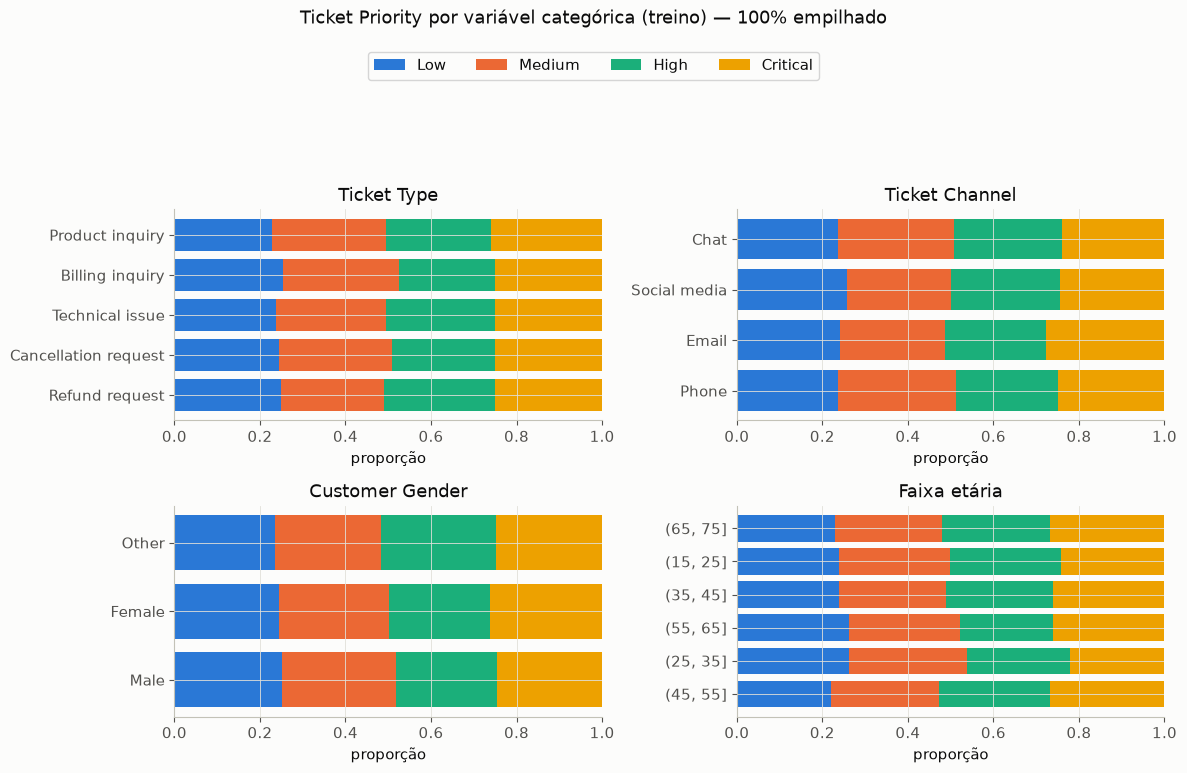

In [4]:
age_bucket = pd.cut(df["Customer Age"], bins=[15, 25, 35, 45, 55, 65, 75])
df_age = df.assign(**{"Faixa etária": age_bucket.astype(str)})

grid_cols = [
    ("Ticket Type", df),
    ("Ticket Channel", df),
    ("Customer Gender", df),
    ("Faixa etária", df_age),
]

max_deviations = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for (col, data), ax in zip(grid_cols, axes.flat):
    ct = priority_crosstab(data, col)
    plot_stacked_priority(ax, ct, col)
    max_deviations[col] = report_max_deviation(col, ct)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("Ticket Priority por variável categórica (treino) — 100% empilhado", y=1.1)
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()

In [5]:
ct_product = priority_crosstab(df, "Product Purchased", top_n=10)
max_deviations["Product Purchased (top 10)"] = report_max_deviation("Product Purchased (top 10)", ct_product)
deviation_table(ct_product).style.background_gradient(cmap="RdBu_r", vmin=-15, vmax=15).format("{:.1f}")

Product Purchased (top 10): desvio máximo da taxa base = 9.2 p.p.


Ticket Priority,Low,Medium,High,Critical
Product Purchased,,,,
Canon EOS,-2.5,-4.6,3.9,3.3
Amazon Echo,3.5,-1.0,-1.6,-1.0
LG Washing Machine,-9.2,2.6,3.9,2.6
Nest Thermostat,1.9,0.4,-4.7,2.4
Roomba Robot Vacuum,-2.3,-3.8,2.0,4.0
Fitbit Charge,-3.9,-2.2,6.3,-0.2
Apple AirPods,-3.3,-0.9,5.0,-0.9
GoPro Hero,5.5,-5.3,-4.1,3.9
Sony Xperia,-1.2,7.3,-6.7,0.6


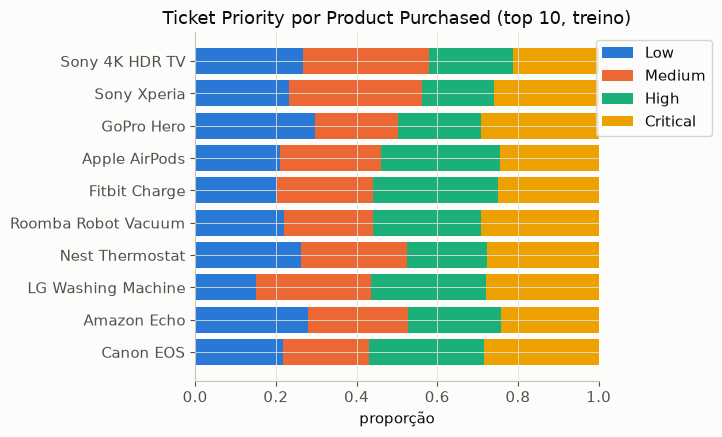

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_stacked_priority(ax, ct_product, "Ticket Priority por Product Purchased (top 10, treino)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

In [7]:
ct_subject = priority_crosstab(df, "Ticket Subject", top_n=10)
max_deviations["Ticket Subject (top 10)"] = report_max_deviation("Ticket Subject (top 10)", ct_subject)
deviation_table(ct_subject).style.background_gradient(cmap="RdBu_r", vmin=-15, vmax=15).format("{:.1f}")

Ticket Subject (top 10): desvio máximo da taxa base = 4.8 p.p.


Ticket Priority,Low,Medium,High,Critical
Ticket Subject,,,,
Hardware issue,2.1,-4.7,-0.3,3.0
Refund request,1.3,-2.0,-2.2,2.9
Product compatibility,-3.7,3.0,0.0,0.7
Software bug,4.8,0.9,-2.7,-3.0
Delivery problem,-1.2,2.3,1.5,-2.6
Payment issue,-1.9,0.0,-0.1,2.0
Battery life,-2.2,1.9,1.8,-1.5
Product recommendation,1.3,-2.7,0.5,0.9
Product setup,-0.4,0.2,-2.9,3.1


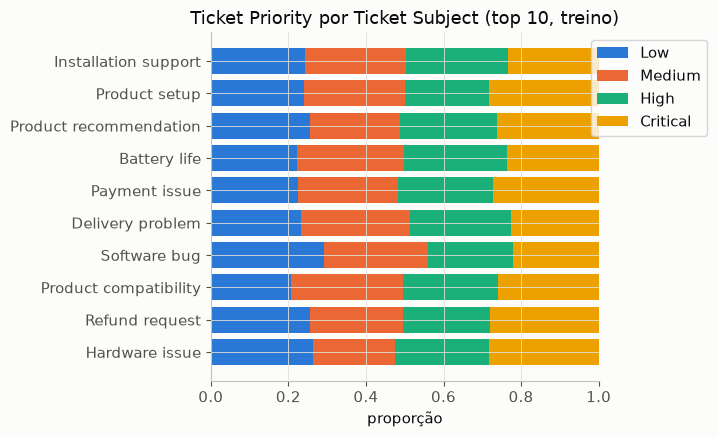


Ranking de desvio máximo da taxa base, por variável:
Product Purchased (top 10)    9.2
Ticket Subject (top 10)       4.8
Faixa etária                  3.2
Ticket Channel                2.5
Customer Gender               2.1
Ticket Type                   2.1
dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_stacked_priority(ax, ct_subject, "Ticket Priority por Ticket Subject (top 10, treino)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

print("\nRanking de desvio máximo da taxa base, por variável:")
print(pd.Series(max_deviations).sort_values(ascending=False).round(1))

Nenhuma variável isolada mostrou desvio muito acima do que se espera por ruído de amostragem: `Ticket Type`, `Ticket Channel` e `Customer Gender` ficaram entre 2.1–2.5 p.p. de desvio máximo, a faixa etária chegou a 3.2 p.p., e os maiores desvios apareceram nos cortes de maior cardinalidade — `Product Purchased` (top 10) com 9.2 p.p. e `Ticket Subject` (top 10) com 4.8 p.p., prováveis efeitos de amostra menor por categoria (~140 tickets por produto, em média) e não um sinal robusto de negócio. Consistente com o achado de `1.1` de baixo poder discriminativo das categóricas isoladas: a expectativa realista para a seção de modelagem é um desempenho próximo do baseline.

## 3. Priority no texto: a descrição carrega sinal?

Verificação rápida (não é o notebook de NLP dedicado já citado em `1.1`) sobre se o texto livre de `Ticket Description` distingue prioridades — útil para decidir se vale a pena incluir TF-IDF no pipeline de modelagem (seção 5).

Ticket Priority
Low         46.2
Medium      46.3
High        47.0
Critical    46.2
Name: Ticket Description, dtype: float64


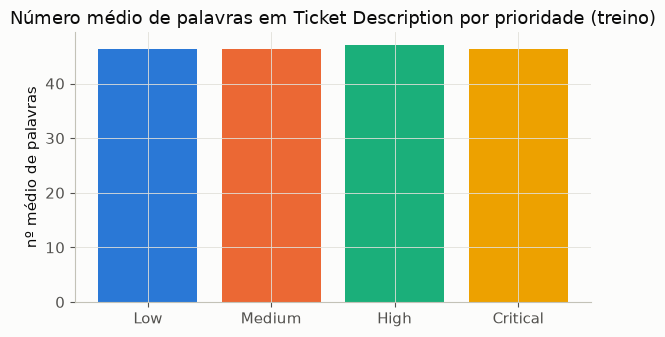

In [9]:
word_count = df["Ticket Description"].str.split().str.len()
mean_words = word_count.groupby(df["Ticket Priority"]).mean().reindex(PRIORITY_ORDER)
print(mean_words.round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(mean_words.index, mean_words.values, color=CATEGORICAL_PALETTE[:4])
ax.set_title("Número médio de palavras em Ticket Description por prioridade (treino)")
ax.set_ylabel("nº médio de palavras")
plt.tight_layout()
plt.show()

In [10]:
tfidf_probe = TfidfVectorizer(max_features=30, stop_words="english")
tfidf_matrix = tfidf_probe.fit_transform(df["Ticket Description"])
terms = np.array(tfidf_probe.get_feature_names_out())

for priority in PRIORITY_ORDER:
    mask = (df["Ticket Priority"] == priority).to_numpy()
    mean_weights = np.asarray(tfidf_matrix[mask].mean(axis=0)).ravel()
    top_idx = mean_weights.argsort()[::-1][:8]
    print(f"{priority}: {', '.join(terms[top_idx])}")

Low: product_purchased, issue, having, assist, ve, product, problem, data
Medium: product_purchased, issue, assist, having, ve, product, problem, steps
High: product_purchased, issue, having, assist, ve, product, problem, data
Critical: product_purchased, issue, assist, having, ve, product, data, problem


Confirmado: a contagem média de palavras é praticamente idêntica entre as quatro classes (46.2 a 47.0 palavras) e os termos de maior peso TF-IDF se repetem quase exatamente entre prioridades (`product_purchased`, `issue`, `having`, `assist`, `product`, `problem` aparecem no top 8 de todas as classes) — consistente com a hipótese de texto templado levantada em `1.1`: o conteúdo textual, isoladamente, não distingue prioridades.

**Decisão:** mesmo com sinal visual fraco, `Ticket Description` via TF-IDF permanece no pipeline de modelagem (seção 5) — é barato de calcular, permite ao modelo capturar sinal residual que a inspeção manual não capta, e possibilita uma comparação honesta "o texto ajudou?" na seção 9. `Resolution` não entra em nenhuma etapa: só existe para tickets `Closed` (ver exclusão na seção 5).

## 4. Consistência da distribuição entre treino/val/teste

`_group_level_split` (`customer_support_analytics/dataset.py`) estratifica pelo valor de `Ticket Priority` **mais frequente por `Customer Email`**, não por linha — a preservação da distribuição entre splits é aproximada, não garantida, e vale conferir.

                 train   val  test
Ticket Priority                   
Low               24.3  24.4  24.5
Medium            25.9  25.8  26.1
High              24.6  24.7  24.6
Critical          25.2  25.1  24.8


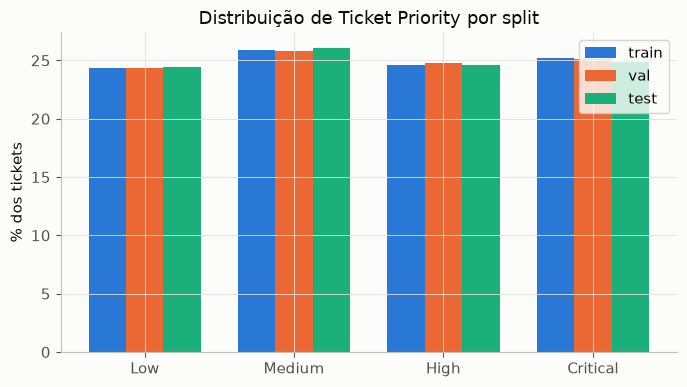


Maior gap entre splits, por classe: 0.4 p.p.


In [11]:
val_df = pd.read_csv(PROCESSED_DATA_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

split_dist = pd.DataFrame({
    "train": df["Ticket Priority"].value_counts(normalize=True),
    "val": val_df["Ticket Priority"].value_counts(normalize=True),
    "test": test_df["Ticket Priority"].value_counts(normalize=True),
}).reindex(PRIORITY_ORDER) * 100
print(split_dist.round(1))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(PRIORITY_ORDER))
width = 0.25
for i, split_name in enumerate(["train", "val", "test"]):
    ax.bar(x + i * width, split_dist[split_name], width, label=split_name, color=CATEGORICAL_PALETTE[i])
ax.set_xticks(x + width)
ax.set_xticklabels(PRIORITY_ORDER)
ax.set_ylabel("% dos tickets")
ax.set_title("Distribuição de Ticket Priority por split")
ax.legend()
plt.tight_layout()
plt.show()

max_gap = (split_dist.max(axis=1) - split_dist.min(axis=1)).max()
print(f"\nMaior gap entre splits, por classe: {max_gap:.1f} p.p.")

Distribuições praticamente idênticas entre os três splits (maior gap entre classes de apenas 0.4 p.p.) — a estratificação por pseudo-rótulo de grupo em `_group_level_split` preservou bem o balanceamento de `Ticket Priority`, mesmo estratificando por cliente e não por linha.

## 5. Preparação de atributos para modelagem

**Atributos incluídos** (todos disponíveis no momento de criação/triagem do ticket):

| Coluna | Transformador | Motivo |
|---|---|---|
| `Ticket Type`, `Ticket Channel`, `Customer Gender`, `Product Purchased`, `Ticket Subject` | `OneHotEncoder` | categóricas conhecidas na criação do ticket |
| `Customer Age` | `StandardScaler` | numérica, conhecida na criação |
| `Ticket Description` | `TfidfVectorizer` | texto livre — decisão da seção 3 |
| `Date of Purchase` → `purchase_month` | `OneHotEncoder` | sazonalidade de compra; `1.1` (seção 8) já mostrou que é data de *compra*, não de abertura do ticket — um coeficiente fraco aqui não seria surpresa |

**Atributos excluídos:**

| Coluna | Motivo |
|---|---|
| `Ticket ID`, `Customer Name`, `Customer Email` | identificadores; `Customer Email` também é a chave de agrupamento do split |
| `Customer Satisfaction Rating` | vazamento de alvo — só existe pós-resolução, portanto posterior à atribuição de prioridade (e `1.1` seção 9 já não achou sinal, mesmo ignorando o vazamento) |
| `First Response Time`, `Time to Resolution` | sinalizados como provavelmente sintéticos/não confiáveis em `1.1` (seção 10) |
| `Resolution` | só existe para tickets `Closed` — é um proxy de `Ticket Status`, informação posterior à triagem |
| `Ticket Status` | campo de estágio do ciclo de vida, não disponível de forma estável no momento da triagem; usá-lo criaria um atalho Status→Priority que não generalizaria para um cenário real |

In [12]:
def add_purchase_month(data):
    data = data.copy()
    data["purchase_month"] = pd.to_datetime(data["Date of Purchase"]).dt.month.astype(str)
    return data


df_feat = add_purchase_month(df)
val_feat = add_purchase_month(val_df)
test_feat = add_purchase_month(test_df)

CATEGORICAL_FEATURES = [
    "Ticket Type", "Ticket Channel", "Customer Gender", "Product Purchased",
    "Ticket Subject", "purchase_month",
]
NUMERIC_FEATURES = ["Customer Age"]
TEXT_FEATURE = "Ticket Description"
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES + [TEXT_FEATURE]
TARGET_COLUMN = "Ticket Priority"

preprocessor = ColumnTransformer(transformers=[
    ("text", TfidfVectorizer(max_features=300, stop_words="english"), TEXT_FEATURE),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])

X_train, y_train = df_feat[FEATURE_COLUMNS], df_feat[TARGET_COLUMN]
X_val, y_val = val_feat[FEATURE_COLUMNS], val_feat[TARGET_COLUMN]
X_test, y_test = test_feat[FEATURE_COLUMNS], test_feat[TARGET_COLUMN]

print("train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

train: (5920, 8) | val: (1273, 8) | test: (1276, 8)


## 6. Baseline e candidatos de modelo

Baseline `DummyClassifier(strategy="stratified")` (respeita o balanceamento das classes sem usar nenhum atributo) contra três modelos que a combinação esparsa TF-IDF + one-hot suporta bem, todos já disponíveis em `scikit-learn` (nenhuma dependência nova). `class_weight="balanced"` é uma escolha de segurança leve — as classes já são quase uniformes, então o efeito prático deve ser pequeno.

In [13]:
candidates = {
    "Baseline (estratificado)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVC": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"
    ),
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("clf", clf)])
    for name, clf in candidates.items()
}

## 7. Seleção do modelo (comparação em val.csv)

Cada candidato é treinado em `train.csv` e avaliado em `val.csv`. Métrica principal: **macro-F1** (robusta independente do balanceamento das classes). Sem k-fold: o repositório já fornece um split fixo treino/val para exatamente esse fim — introduzir k-fold dentro do treino divergiria do fluxo já estabelecido em `dataset.py`.

In [14]:
results = []
val_predictions = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    val_predictions[name] = y_pred
    results.append({
        "modelo": name,
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "macro_precision": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_val, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).set_index("modelo").sort_values("macro_f1", ascending=False)
results_df.round(3)

,accuracy,macro_f1,macro_precision,macro_recall
modelo,,,,
Random Forest,0.263,0.263,0.263,0.263
Logistic Regression,0.249,0.249,0.249,0.249
Linear SVC,0.247,0.246,0.246,0.246
Baseline (estratificado),0.229,0.229,0.230,0.229


In [15]:
for name, y_pred in val_predictions.items():
    print(f"=== {name} ===")
    print(classification_report(y_val, y_pred, digits=3, zero_division=0))

=== Baseline (estratificado) ===
              precision    recall  f1-score   support

    Critical      0.215     0.228     0.222       320
        High      0.219     0.213     0.216       315
         Low      0.247     0.229     0.238       310
      Medium      0.238     0.247     0.242       328

    accuracy                          0.229      1273
   macro avg      0.230     0.229     0.229      1273
weighted avg      0.230     0.229     0.229      1273

=== Logistic Regression ===
              precision    recall  f1-score   support

    Critical      0.209     0.203     0.206       320
        High      0.268     0.270     0.269       315
         Low      0.231     0.239     0.235       310
      Medium      0.287     0.284     0.285       328

    accuracy                          0.249      1273
   macro avg      0.249     0.249     0.249      1273
weighted avg      0.249     0.249     0.249      1273

=== Linear SVC ===
              precision    recall  f1-score   supp

In [16]:
winner_name = results_df.index[0]
print(f"Modelo vencedor (maior macro-F1 em val): {winner_name} "
      f"(macro-F1 = {results_df.loc[winner_name, 'macro_f1']:.3f})")

Modelo vencedor (maior macro-F1 em val): Random Forest (macro-F1 = 0.263)


## 8. Avaliação final (test.csv)

`test.csv` é tocado **uma única vez**, aqui. O pipeline vencedor já foi treinado apenas em `train.csv` (seção 7, sem refit em treino+val) — mantendo a separação ajuste/comparação/avaliação-final já estabelecida no repositório.

Accuracy (test): 0.245
Macro-F1 (test): 0.244
              precision    recall  f1-score   support

    Critical      0.252     0.278     0.264       317
        High      0.256     0.245     0.250       314
         Low      0.187     0.179     0.183       312
      Medium      0.281     0.276     0.279       333

    accuracy                          0.245      1276
   macro avg      0.244     0.245     0.244      1276
weighted avg      0.245     0.245     0.245      1276



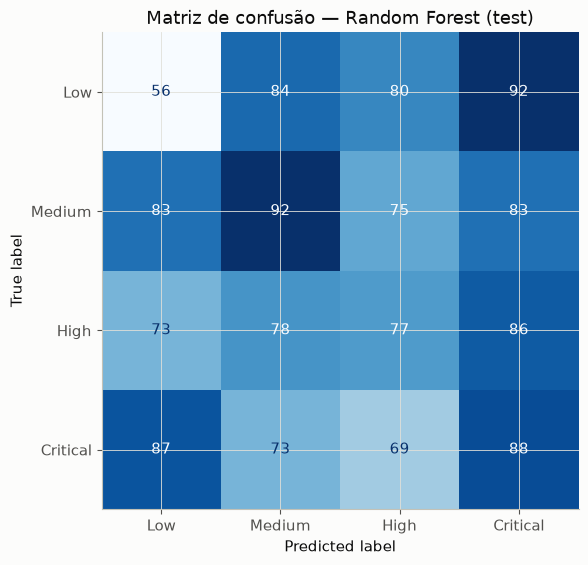


Macro-F1 em val: 0.263 | Macro-F1 em test: 0.244 (diferença: -0.019)


In [17]:
winner_pipeline = pipelines[winner_name]
y_test_pred = winner_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
print(f"Accuracy (test): {test_accuracy:.3f}")
print(f"Macro-F1 (test): {test_macro_f1:.3f}")
print(classification_report(y_test, y_test_pred, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, labels=PRIORITY_ORDER, ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Matriz de confusão — {winner_name} (test)")
plt.tight_layout()
plt.show()

val_macro_f1 = results_df.loc[winner_name, "macro_f1"]
print(f"\nMacro-F1 em val: {val_macro_f1:.3f} | Macro-F1 em test: {test_macro_f1:.3f} "
      f"(diferença: {test_macro_f1 - val_macro_f1:+.3f})")

O Random Forest venceu a comparação em val (macro-F1 = 0.263) e manteve desempenho parecido em test (macro-F1 = 0.244, accuracy = 0.245) — uma queda de 0.019 entre val e test, pequena o suficiente para não indicar overfitting relevante ao processo de seleção. Em termos absolutos, o ganho sobre o baseline estratificado (macro-F1 ≈ 0.229 em val) é modesto: cerca de 3 pontos percentuais de macro-F1.

## 9. O que mais pesa na decisão do modelo

Voltando à pergunta da seção 2: quais atributos o modelo vencedor mais usa para decidir a prioridade?

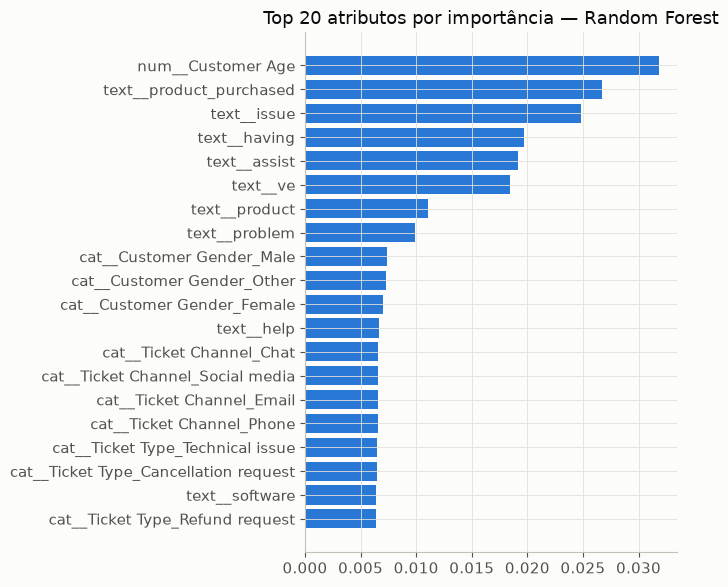

In [18]:
clf = winner_pipeline.named_steps["clf"]
feature_names = winner_pipeline.named_steps["preprocessor"].get_feature_names_out()

if hasattr(clf, "coef_"):
    coefs = pd.DataFrame(clf.coef_, index=clf.classes_, columns=feature_names)
    fig, axes = plt.subplots(1, len(clf.classes_), figsize=(4.5 * len(clf.classes_), 5.5))
    for cls, ax in zip(clf.classes_, axes):
        top = coefs.loc[cls].sort_values()
        top = pd.concat([top.head(10), top.tail(10)])
        ax.barh(top.index, top.values, color=BLUE)
        ax.set_title(f"Priority = {cls}")
    fig.suptitle(f"Top coeficientes por classe — {winner_name}", y=1.03)
    plt.tight_layout()
    plt.show()
elif hasattr(clf, "feature_importances_"):
    importances = (
        pd.Series(clf.feature_importances_, index=feature_names)
        .sort_values(ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(importances.index[::-1], importances.values[::-1], color=BLUE)
    ax.set_title(f"Top 20 atributos por importância — {winner_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{winner_name} não expõe coef_ nem feature_importances_.")

A importância das features do Random Forest está bastante diluída: as 20 features mais importantes (de um total de 383) respondem por apenas ~24% da importância total, e nenhuma feature isolada se destaca (a mais importante, `Customer Age`, tem apenas 3.2%). Os termos textuais mais influentes (`product_purchased`, `issue`, `having`, `assist`, `product`, `problem`) são exatamente os mesmos termos genéricos identificados na seção 3 como comuns a todas as prioridades — o modelo não encontrou um vocabulário distintivo por prioridade, só ruído com viés estatístico pequeno. Isso confirma o que a análise exploratória já sugeria na seção 2: nenhuma variável isolada carrega sinal forte sobre `Ticket Priority`; o desempenho ficou próximo do baseline estratificado, o que é consistente com os dados e não indica um problema de implementação do pipeline.

## 10. Resumo dos principais achados

- **Categóricas sem sinal relevante:** `Ticket Type`, `Ticket Channel`, `Customer Gender` e faixa etária tiveram desvio máximo da taxa base entre 2.1 e 3.2 p.p.; cortes de maior cardinalidade (`Product Purchased`, `Ticket Subject`) chegaram a 9.2 p.p., provável efeito de amostra pequena por categoria.
- **Texto sem sinal relevante:** contagem de palavras e termos TF-IDF de maior peso em `Ticket Description` são quase idênticos entre as quatro prioridades — reforça a hipótese de texto templado de `1.1`.
- **Split consistente:** a distribuição de `Ticket Priority` entre treino/val/teste variou no máximo 0.4 p.p. — a estratificação por grupo funcionou bem na prática.
- **Modelo final perto do baseline:** o Random Forest venceu a comparação (macro-F1 = 0.263 em val, 0.244 em test) contra um baseline estratificado de macro-F1 ≈ 0.229 — ganho de só ~3 p.p., com importância de features bastante diluída (sem nenhum atributo dominante).
- **Vazamentos e exclusões:** `Customer Satisfaction Rating`, `Resolution` e `Ticket Status` foram excluídos por vazamento de alvo/escopo de triagem; `First Response Time` e `Time to Resolution` foram excluídos por confiabilidade (ver `1.1`, seção 10).
- **Conclusão:** com os atributos disponíveis neste dataset, `Ticket Priority` parece ser atribuída de forma aproximadamente independente das demais colunas — um resultado honesto da análise, não uma falha do pipeline de modelagem.

## 11. Próximos passos

1. **Promover o pipeline vencedor** (`ColumnTransformer` + modelo) para `customer_support_analytics/features.py` (engenharia de `purchase_month` etc.) e `customer_support_analytics/modeling/train.py`/`predict.py`, hoje ainda stubs do cookiecutter, para permitir treino/inferência fora do notebook.
2. **Testar TF-IDF com n-gramas (1,2)** ou vocabulário maior, e revisitar a hipótese de texto templado com uma análise dedicada de NLP (já citada em `1.1`).
3. **Reavaliar `First Response Time`/`Time to Resolution`** como atributos caso sejam validados como reais numa fonte de dados futura (hoje excluídos por confiabilidade, não por princípio).
4. **Revisitar técnicas de desbalanceamento** (`imbalanced-learn` não está disponível hoje) se um dataset futuro for menos uniforme do que este.
5. **Formalizar o recorte "prioridade no momento da triagem"**: remover explicitamente qualquer campo pós-criação do ticket em `dataset.py`/`features.py`, não só no notebook.